   Time  Amount  Location  MerchantType  TransactionType  Class
0     1     509         3             2                1      0
1     2   21717         5             1                2      1
2     3   21140         2             2                1      1
3     4   11831         5             4                1      0
4     5    4657         1             2                2      0


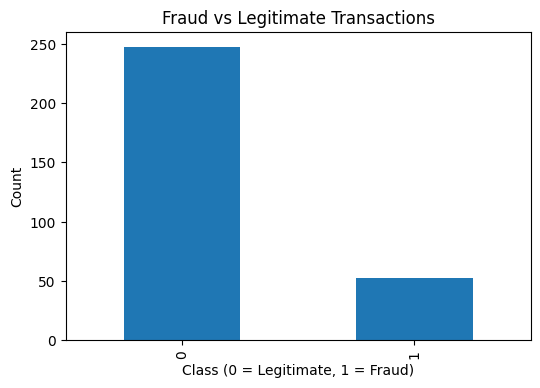

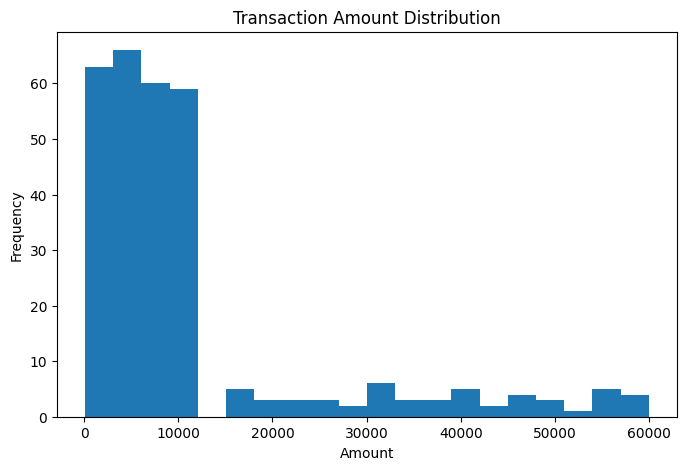

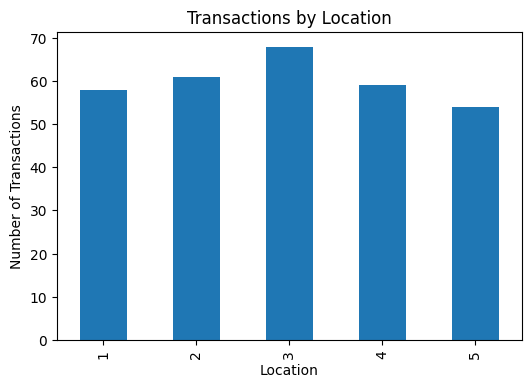

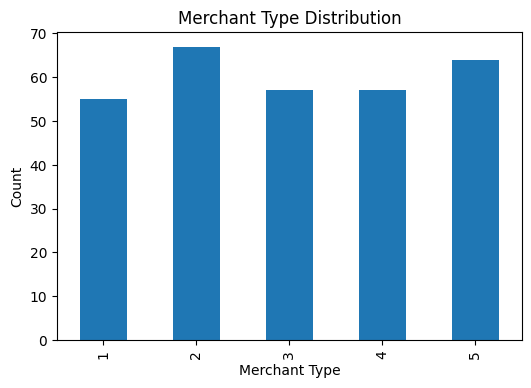


Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00         8

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


Fraudulent Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
df = pd.read_csv("creditcard.csv")

# Display first 5 rows
print(df.head())

# -------------------------------
# Data Visualization
# -------------------------------

# 1. Fraud vs Legitimate Transactions
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# 2. Transaction Amount Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=20)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# 3. Location Distribution
plt.figure(figsize=(6,4))
df['Location'].value_counts().sort_index().plot(kind='bar')
plt.title("Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")
plt.show()

# 4. Merchant Type Distribution
plt.figure(figsize=(6,4))
df['MerchantType'].value_counts().sort_index().plot(kind='bar')
plt.title("Merchant Type Distribution")
plt.xlabel("Merchant Type")
plt.ylabel("Count")
plt.show()

# -------------------------------
# Machine Learning
# -------------------------------

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# -------------------------------
# Prediction
# -------------------------------

sample = [[301, 35000, 5, 4, 2]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\nFraudulent Transaction")
else:
    print("\nLegitimate Transaction")